# Deep Deterministic Policy Gradient (DDPG)

**A hands-on tutorial with theory and PyTorch implementation**

---

DQN cracked Atari, but its central operation — $\max_{a'} Q(s', a')$ — requires enumerating actions. It cannot
control a robot arm whose action is a vector of joint torques. **DDPG**
([Lillicrap et al., 2016](https://arxiv.org/abs/1509.02971)) was DeepMind's answer: combine the **deterministic
policy gradient** theorem (Silver et al., 2014) with the two DQN stabilizers, experience replay and target networks,
and train an *actor* network to output the maximizing action directly. The result was the first deep RL algorithm to
solve a broad range of continuous-control tasks (over 20 simulated physics problems, several from pixels) end-to-end,
and it opened the door to deep RL in robotics.

DDPG is famously finicky — but its architecture (actor, critic, replay buffer, soft target updates, exploration noise)
is the skeleton of every off-policy continuous-control method that followed, including TD3 and SAC in the next
two notebooks.

## What you will learn

1. Why $\max_a Q(s,a)$ is the obstacle for continuous actions, and how a **deterministic actor** replaces it.
2. The **deterministic policy gradient** theorem and its low-variance appeal.
3. **Soft (Polyak) target updates** and **exploration noise** (Ornstein–Uhlenbeck and Gaussian).
4. A **from-scratch PyTorch implementation** on `Pendulum-v1`.
5. DDPG's failure modes and how TD3 and SAC address them.

## Notebook outline

1. Continuous actions: the problem with $\max_a$
2. The deterministic policy gradient
3. The DDPG algorithm
4. Exploration in continuous action spaces
5. Implementation
6. Training on Pendulum
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. Continuous Actions: The Problem with $\max_a$

Q-learning improves the policy by taking the greedy action, $\pi(s) = \arg\max_a Q(s,a)$, and forms its target with
$\max_{a'} Q(s',a')$. With a handful of discrete actions this is a table lookup. With $a \in \mathbb{R}^d$ it is an
*optimization problem* that would have to be solved at every step of every update — with a non-convex neural-network
$Q$, that is hopeless. Discretizing the action space does not help either: $d$ joints with $k$ levels each gives $k^d$
actions.

Policy gradient methods (REINFORCE, A2C, TRPO, PPO) handle continuous actions naturally with a Gaussian policy, but
they are **on-policy** and therefore sample-hungry — a real problem when each sample means moving a physical robot.

DDPG's idea: keep the off-policy, replay-based training of DQN, but *learn the $\arg\max$*. Train a deterministic
**actor** $\mu_\theta(s)$ so that $\mu_\theta(s) \approx \arg\max_a Q_\phi(s,a)$, and use it wherever DQN would take a max:

$$
y = r + \gamma\, Q_{\phi^-}\big(s',\, \mu_{\theta^-}(s')\big).
$$

## 2. The Deterministic Policy Gradient

For a deterministic policy $a = \mu_\theta(s)$, the objective is $J(\theta) = \mathbb{E}_{s \sim d^\mu}[Q^\mu(s, \mu_\theta(s))]$.
Silver et al. (2014) proved the **deterministic policy gradient theorem**:

$$
\boxed{\;\nabla_\theta J(\theta) \;=\; \mathbb{E}_{s \sim d^\mu}\Big[\, \nabla_a Q^\mu(s,a)\big|_{a = \mu_\theta(s)}\; \nabla_\theta \mu_\theta(s) \,\Big]\;}
$$

Read it as the chain rule: the policy parameters affect the action, the action affects $Q$. Compared to the stochastic
policy gradient $\mathbb{E}[\nabla_\theta \log\pi_\theta(a|s)\, Q(s,a)]$, this expectation is over **states only**, not
over actions — so it has much lower variance, especially in high-dimensional action spaces. The price is that it
requires the critic's gradient with respect to the action, $\nabla_a Q$, which is fine for a neural-network critic.

In practice, with a learned critic $Q_\phi$, the actor update is simply gradient **ascent** on

$$
J_{\text{actor}}(\theta) = \mathbb{E}_{s \sim \mathcal{D}}\big[\, Q_\phi(s, \mu_\theta(s)) \,\big],
$$

which autograd computes by backpropagating through the critic into the actor. The critic parameters are held fixed
during this step.

## 3. The DDPG Algorithm

**Critic** $Q_\phi(s,a)$: trained exactly like DQN, by regression on a bootstrapped target computed with *target*
networks:

$$
L(\phi) = \mathbb{E}_{(s,a,r,s',d) \sim \mathcal{D}}\Big[\big(\, r + \gamma (1-d)\, Q_{\phi^-}(s', \mu_{\theta^-}(s')) - Q_\phi(s,a)\big)^2\Big].
$$

**Actor** $\mu_\theta(s)$: gradient ascent on $\mathbb{E}_{s \sim \mathcal{D}}[Q_\phi(s, \mu_\theta(s))]$.

**Target networks** $\phi^-, \theta^-$: instead of DQN's periodic hard copy, DDPG introduced **soft (Polyak) updates**
after every step,

$$
\phi^- \leftarrow \tau\phi + (1-\tau)\phi^-, \qquad \theta^- \leftarrow \tau\theta + (1-\tau)\theta^-, \qquad \tau \ll 1 \ (\text{e.g. } 0.005),
$$

so the targets track the online networks slowly and smoothly. This has since become the default in off-policy RL.

**Replay buffer** $\mathcal{D}$: as in DQN. DDPG is fully off-policy, so the buffer can contain data from any policy.

**Algorithm (one environment step):**

1. Act with exploration noise: $a = \mu_\theta(s) + \mathcal{N}$; store $(s,a,r,s',d)$ in $\mathcal{D}$.
2. Sample a minibatch; update the critic by one gradient step on $L(\phi)$.
3. Update the actor by one gradient step on $-\mathbb{E}[Q_\phi(s,\mu_\theta(s))]$.
4. Soft-update both target networks.

The original paper also used batch normalization to handle observations with different scales, and a
per-dimension action scaling; we use a `tanh` output scaled to the action bounds instead.

## 4. Exploration in Continuous Action Spaces

A deterministic policy never explores on its own, so DDPG adds noise to the *action* at collection time. The paper used
an **Ornstein–Uhlenbeck (OU) process**, a temporally correlated noise from physics:

$$
x_{t+1} = x_t + \theta_{\text{OU}}(\mu - x_t) + \sigma\, \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, 1),
$$

whose autocorrelation produces smooth, "inertial" perturbations well suited to physical systems. Later work (TD3, SAC)
found that plain **uncorrelated Gaussian noise** $\mathcal{N}(0, \sigma^2)$ works just as well and is simpler; we implement
both and use OU by default to stay faithful to the original. We also start with a few thousand steps of **uniformly
random actions** to seed the replay buffer with diverse data before learning begins.

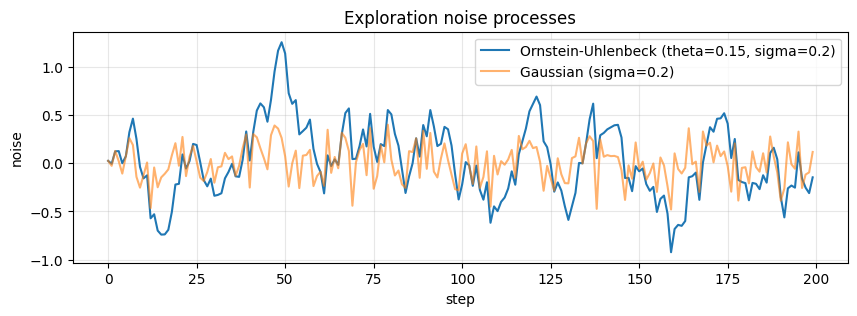

In [4]:
class OrnsteinUhlenbeckNoise:
    """Temporally correlated exploration noise (Uhlenbeck & Ornstein, 1930), as used in the DDPG paper."""
    def __init__(self, size, mu=0.0, theta=0.15, sigma=0.2, seed=0):
        self.mu, self.theta, self.sigma = mu, theta, sigma
        self.rng = np.random.default_rng(seed)
        self.x = np.full(size, mu, dtype=np.float32)

    def reset(self):
        self.x[:] = self.mu

    def sample(self):
        self.x += self.theta * (self.mu - self.x) + self.sigma * self.rng.standard_normal(self.x.shape).astype(np.float32)
        return self.x.copy()


class GaussianNoise:
    def __init__(self, size, sigma=0.1, seed=0):
        self.size, self.sigma, self.rng = size, sigma, np.random.default_rng(seed)
    def reset(self): pass
    def sample(self):
        return (self.sigma * self.rng.standard_normal(self.size)).astype(np.float32)


# What the two kinds of noise look like over 200 steps
ou, g = OrnsteinUhlenbeckNoise(1), GaussianNoise(1, sigma=0.2)
plt.figure(figsize=(10, 3))
plt.plot([ou.sample()[0] for _ in range(200)], label="Ornstein-Uhlenbeck (theta=0.15, sigma=0.2)")
plt.plot([g.sample()[0] for _ in range(200)], alpha=0.6, label="Gaussian (sigma=0.2)")
plt.xlabel("step"); plt.ylabel("noise"); plt.title("Exploration noise processes"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Implementation

### 5.1 The environment and hyperparameters

`Pendulum-v1`: swing a pendulum up and hold it upright. Observation is $(\cos\theta, \sin\theta, \dot\theta)$, the action
is a torque in $[-2, 2]$, and the reward is $-(\theta^2 + 0.1\dot\theta^2 + 0.001 u^2)$ per step — always negative,
close to $0$ when the pendulum is balanced. Episodes last 200 steps; a random policy scores about $-1200$ and a good
policy $-150$ or better (the torque is too weak to lift the pendulum directly, so it has to swing back and forth first).

In [5]:
@dataclass
class DDPGConfig:
    env_id: str = "Pendulum-v1"
    total_timesteps: int = 25_000
    learning_starts: int = 2_000        # random actions to seed the buffer
    buffer_size: int = 100_000
    batch_size: int = 256
    gamma: float = 0.99
    tau: float = 0.005                  # Polyak averaging coefficient
    actor_lr: float = 1e-3
    critic_lr: float = 1e-3
    hidden: int = 256
    noise: str = "ou"                   # "ou" | "gaussian"
    noise_sigma: float = 0.2            # in units of the normalized action [-1, 1]
    eval_interval: int = 1_000
    eval_episodes: int = 5


cfg = DDPGConfig()
print(cfg)

DDPGConfig(env_id='Pendulum-v1', total_timesteps=25000, learning_starts=2000, buffer_size=100000, batch_size=256, gamma=0.99, tau=0.005, actor_lr=0.001, critic_lr=0.001, hidden=256, noise='ou', noise_sigma=0.2, eval_interval=1000, eval_episodes=5)


### 5.2 Actor, critic, replay buffer

- The **actor** ends in `tanh`, scaled by the action bound, so its outputs are always valid actions.
- The **critic** takes the state and the action *concatenated* as input (the paper injected the action at the second
  layer; concatenating at the input is now standard and works equally well).

In [6]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, act_limit, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, act_dim), nn.Tanh())
        self.act_limit = act_limit

    def forward(self, obs):
        return self.act_limit * self.net(obs)


class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))

    def forward(self, obs, act):
        return self.net(torch.cat([obs, act], dim=-1)).squeeze(-1)


class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim):
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.obs = np.zeros((capacity, obs_dim), np.float32); self.next_obs = np.zeros((capacity, obs_dim), np.float32)
        self.act = np.zeros((capacity, act_dim), np.float32); self.rew = np.zeros(capacity, np.float32); self.done = np.zeros(capacity, np.float32)

    def add(self, o, a, r, o2, d):
        i = self.ptr
        self.obs[i], self.act[i], self.rew[i], self.next_obs[i], self.done[i] = o, a, r, o2, d
        self.ptr = (self.ptr + 1) % self.capacity; self.size = min(self.size + 1, self.capacity)

    def sample(self, n):
        idx = np.random.randint(0, self.size, n)
        f = lambda x: torch.as_tensor(x[idx], device=device)
        return f(self.obs), f(self.act), f(self.rew), f(self.next_obs), f(self.done)


def soft_update(target, source, tau):
    with torch.no_grad():
        for p_t, p in zip(target.parameters(), source.parameters()):
            p_t.mul_(1 - tau).add_(tau * p)

### 5.3 The DDPG update

Critic step, actor step, soft target updates — in that order. Note that the actor's loss is `-Q(s, mu(s)).mean()`, and
that we only step the actor's optimizer, so the critic is unchanged by the actor step even though gradients flow through it.

In [7]:
def ddpg_update(actor, critic, actor_targ, critic_targ, actor_opt, critic_opt, batch, cfg):
    obs, act, rew, next_obs, done = batch

    # ---- critic: regress onto the bootstrapped target built with the target networks ----
    with torch.no_grad():
        target_q = rew + cfg.gamma * (1 - done) * critic_targ(next_obs, actor_targ(next_obs))
    critic_loss = F.mse_loss(critic(obs, act), target_q)
    critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()

    # ---- actor: deterministic policy gradient, ascend Q(s, mu(s)) ----
    actor_loss = -critic(obs, actor(obs)).mean()
    actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()

    # ---- soft target updates ----
    soft_update(critic_targ, critic, cfg.tau)
    soft_update(actor_targ, actor, cfg.tau)
    return critic_loss.item(), -actor_loss.item()

### 5.4 Training loop

The loop is the DQN loop with a deterministic actor plus noise in place of $\varepsilon$-greedy. Every
`eval_interval` steps we run a few noise-free episodes to get a clean learning curve, and keep the best actor.

In [8]:
def evaluate(actor, env_id, n_episodes=5, seed=10_000):
    env = gym.make(env_id); rets = []
    for i in range(n_episodes):
        o, _ = env.reset(seed=seed + i); done, R = False, 0.0
        while not done:
            with torch.no_grad():
                a = actor(torch.as_tensor(o, dtype=torch.float32, device=device)).cpu().numpy()
            o, r, term, trunc, _ = env.step(a); R += r; done = term or trunc
        rets.append(R)
    env.close()
    return float(np.mean(rets))


def train_ddpg(cfg: DDPGConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = gym.make(cfg.env_id); env = gym.wrappers.RecordEpisodeStatistics(env)
    obs_dim, act_dim = env.observation_space.shape[0], env.action_space.shape[0]
    act_limit = float(env.action_space.high[0])

    actor, critic = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device), Critic(obs_dim, act_dim, cfg.hidden).to(device)
    actor_targ, critic_targ = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device), Critic(obs_dim, act_dim, cfg.hidden).to(device)
    actor_targ.load_state_dict(actor.state_dict()); critic_targ.load_state_dict(critic.state_dict())
    actor_opt = torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr)
    critic_opt = torch.optim.Adam(critic.parameters(), lr=cfg.critic_lr)
    buffer = ReplayBuffer(cfg.buffer_size, obs_dim, act_dim)
    noise = OrnsteinUhlenbeckNoise(act_dim, sigma=cfg.noise_sigma, seed=seed) if cfg.noise == "ou" else GaussianNoise(act_dim, cfg.noise_sigma, seed)

    logs = dict(train_returns=[], train_steps=[], eval_steps=[], eval_returns=[], critic_loss=[], q_mean=[], loss_steps=[])
    best_ret, best_state = -np.inf, None
    o, _ = env.reset(seed=seed); env.action_space.seed(seed)
    for step in range(1, cfg.total_timesteps + 1):
        if step <= cfg.learning_starts:
            a = env.action_space.sample()
        else:
            with torch.no_grad():
                a = actor(torch.as_tensor(o, dtype=torch.float32, device=device)).cpu().numpy()
            a = np.clip(a + act_limit * noise.sample(), -act_limit, act_limit)
        o2, r, term, trunc, info = env.step(a)
        buffer.add(o, a, r, o2, float(term))
        o = o2
        if term or trunc:
            logs["train_returns"].append(float(info["episode"]["r"])); logs["train_steps"].append(step)
            o, _ = env.reset(); noise.reset()

        if step > cfg.learning_starts:
            c_loss, q_mean = ddpg_update(actor, critic, actor_targ, critic_targ, actor_opt, critic_opt, buffer.sample(cfg.batch_size), cfg)
            if step % 100 == 0:
                logs["critic_loss"].append(c_loss); logs["q_mean"].append(q_mean); logs["loss_steps"].append(step)

        if step % cfg.eval_interval == 0:
            ret = evaluate(actor, cfg.env_id, cfg.eval_episodes)
            logs["eval_steps"].append(step); logs["eval_returns"].append(ret)
            if ret >= best_ret:
                best_ret, best_state = ret, {k: v.clone() for k, v in actor.state_dict().items()}
            if verbose:
                c = f"{logs['critic_loss'][-1]:8.3f}" if logs["critic_loss"] else "   (n/a)"
                print(f"step {step:6d} | eval return {ret:8.1f} | critic loss {c}")
    env.close()
    best_actor = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device); best_actor.load_state_dict(best_state)
    return actor, best_actor, critic, logs

## 6. Training on Pendulum

In [9]:
t0 = time.time()
actor, best_actor, critic, logs = train_ddpg(cfg)
print(f"\nTrained in {time.time() - t0:.0f}s. Best eval return: {max(logs['eval_returns']):.1f}")

step   1000 | eval return  -1324.4 | critic loss    (n/a)
step   2000 | eval return  -1324.4 | critic loss    (n/a)


step   3000 | eval return  -1294.8 | critic loss    0.053


step   4000 | eval return   -724.2 | critic loss    0.152


step   5000 | eval return   -101.1 | critic loss    0.369


step   6000 | eval return   -102.3 | critic loss    0.597


...

step  21000 | eval return   -108.2 | critic loss    1.288


step  22000 | eval return   -108.6 | critic loss    1.028


step  23000 | eval return   -109.4 | critic loss    1.102


step  24000 | eval return   -107.8 | critic loss    0.903


step  25000 | eval return   -115.8 | critic loss    1.102

Trained in 77s. Best eval return: -97.5


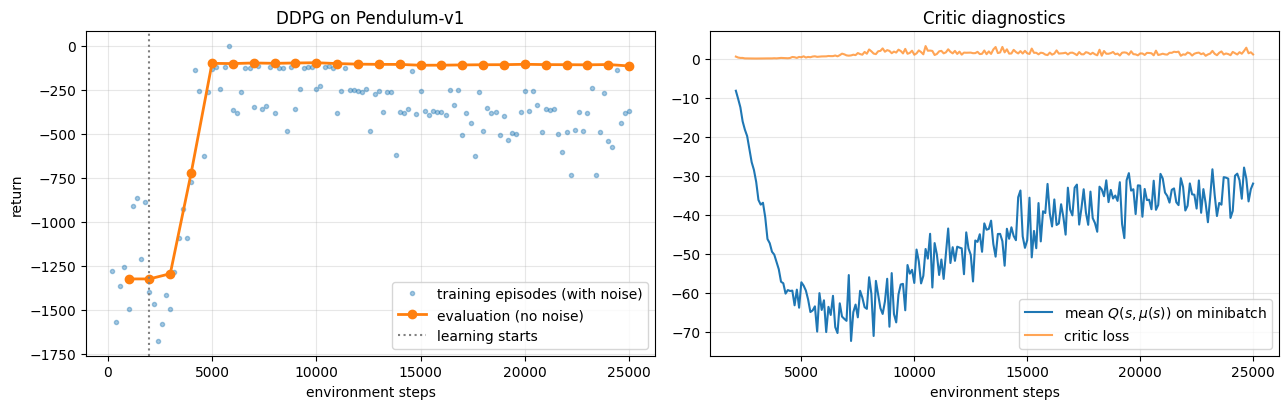

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(logs["train_steps"], logs["train_returns"], ".", alpha=0.4, label="training episodes (with noise)")
axes[0].plot(logs["eval_steps"], logs["eval_returns"], "o-", lw=2, label="evaluation (no noise)")
axes[0].axvline(cfg.learning_starts, color="gray", ls=":", label="learning starts")
axes[0].set_xlabel("environment steps"); axes[0].set_ylabel("return"); axes[0].set_title("DDPG on Pendulum-v1"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(logs["loss_steps"], logs["q_mean"], label=r"mean $Q(s, \mu(s))$ on minibatch")
axes[1].plot(logs["loss_steps"], logs["critic_loss"], alpha=0.7, label="critic loss")
axes[1].set_xlabel("environment steps"); axes[1].set_title("Critic diagnostics"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.** Once learning starts, DDPG typically solves Pendulum within 10–15k steps — far fewer than an
on-policy method would need (PPO takes ~100k+). The mean $Q$ value tracks the (negative) return scale: a good policy's
discounted return is around $-150 \times$ (a factor from the 200-step episode and $\gamma$), and the critic learns to
predict it. Training returns are noisy because of the exploration noise; evaluation returns show the true policy quality.

### 6.1 The learned value landscape

Pendulum's state is essentially two-dimensional (angle and angular velocity), so we can *see* what the critic learned:
$Q(s, \mu(s))$ over the state space. The upright, still state (center) should be the most valuable; states hanging down
with no velocity are the worst, since the pendulum has to pump energy for a while before it can get up.

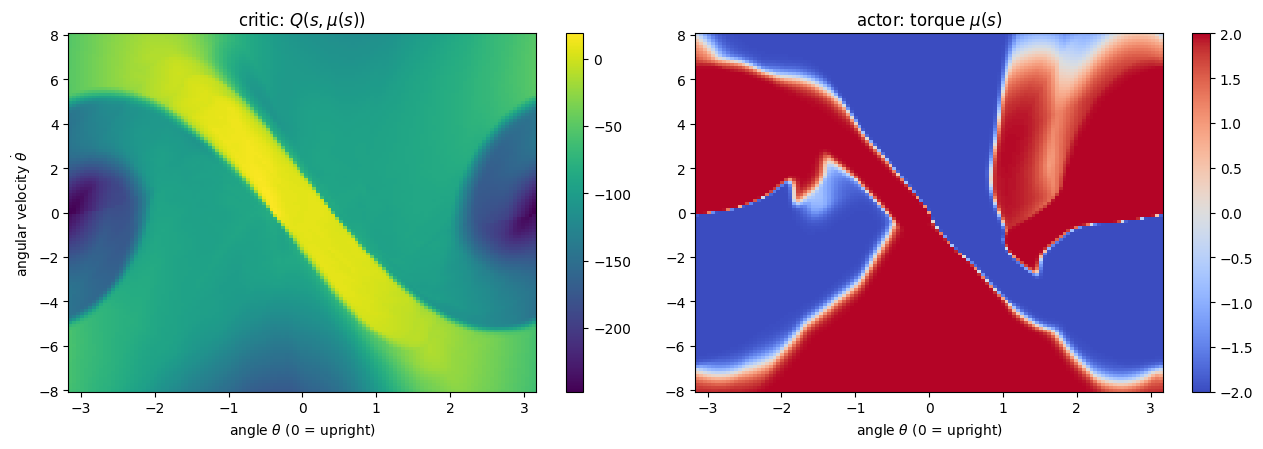

In [11]:
thetas = np.linspace(-np.pi, np.pi, 121); vels = np.linspace(-8, 8, 121)
TH, VEL = np.meshgrid(thetas, vels)
states = torch.as_tensor(np.stack([np.cos(TH), np.sin(TH), VEL], -1).reshape(-1, 3), dtype=torch.float32, device=device)
with torch.no_grad():
    acts = best_actor(states); Qs = critic(states, acts)
Qs, acts = Qs.cpu().numpy().reshape(TH.shape), acts.cpu().numpy().reshape(TH.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
im = axes[0].pcolormesh(TH, VEL, Qs, shading="auto", cmap="viridis"); plt.colorbar(im, ax=axes[0])
axes[0].set_title(r"critic: $Q(s, \mu(s))$"); axes[0].set_xlabel(r"angle $\theta$ (0 = upright)"); axes[0].set_ylabel(r"angular velocity $\dot\theta$")
im = axes[1].pcolormesh(TH, VEL, acts, shading="auto", cmap="coolwarm", vmin=-2, vmax=2); plt.colorbar(im, ax=axes[1])
axes[1].set_title(r"actor: torque $\mu(s)$"); axes[1].set_xlabel(r"angle $\theta$ (0 = upright)")
plt.tight_layout(); plt.show()

## 7. Visual Demonstration

The pendulum starts at a random angle. Watch the actor pump energy (torque in the direction of motion) until it can
swing up, then switch to stabilizing.

Best actor, evaluation over 10 fresh episodes: -108.5


Returns of 5 recorded episodes (different start angles): [-125, -2, -117, -229, -235]; showing the median one (-125.2)


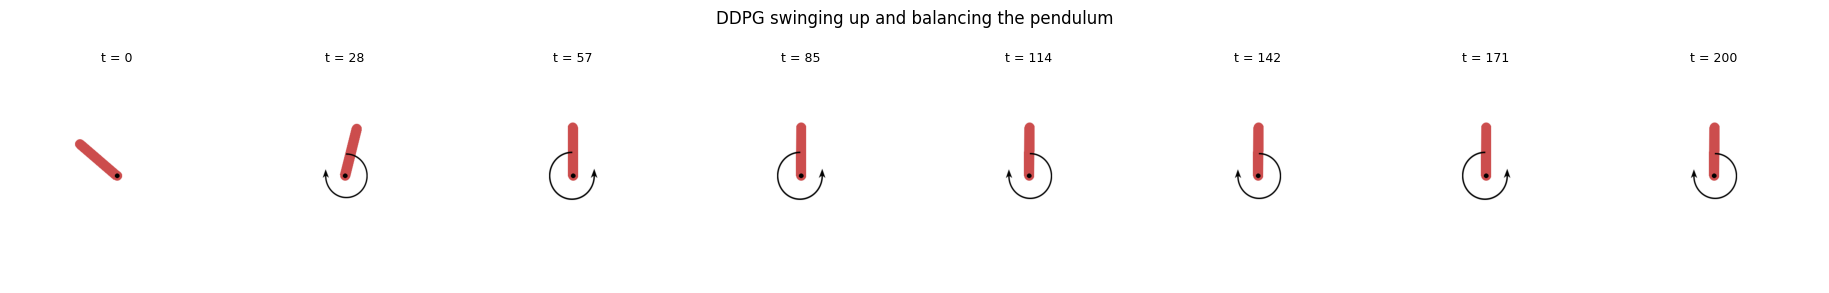

In [12]:
def act_det(obs):
    with torch.no_grad():
        return best_actor(torch.as_tensor(obs, dtype=torch.float32, device=device)).cpu().numpy()

print(f"Best actor, evaluation over 10 fresh episodes: {evaluate(best_actor, cfg.env_id, 10, seed=555):.1f}")
render_env = gym.make(cfg.env_id, render_mode="rgb_array")
episodes = [record_episode(render_env, act_det, seed=s, max_steps=200) for s in range(5)]
render_env.close()
frames, ep_ret, ep_len = sorted(episodes, key=lambda e: e[1])[len(episodes) // 2]   # the median-return episode of 5
print(f"Returns of 5 recorded episodes (different start angles): {[round(e[1]) for e in episodes]}; showing the median one ({ep_ret:.1f})")
show_filmstrip(frames, n=8, title="DDPG swinging up and balancing the pendulum")

Saved media/ddpg_pendulum.gif  (201 frames, 0.30 MB)


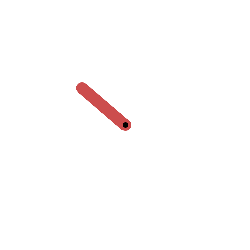

In [13]:
save_gif(frames, "ddpg_pendulum", fps=25)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Continuous actions, off-policy.** Combines the sample efficiency of replay-based learning with continuous control,
  where policy-gradient methods need far more data.
- **Low-variance gradient.** The deterministic policy gradient integrates over states only.
- **Simple architecture** that became the template for all later off-policy actor-critics.

### Weaknesses

- **Brittle.** DDPG is notoriously sensitive to hyperparameters, network initialization and random seeds
  (Henderson et al., 2018); training can diverge late for no visible reason (we kept the best checkpoint for that reason).
- **Over-estimation.** The actor is trained to *exploit* the critic: it finds actions where $Q_\phi$ is over-estimated,
  which then feed back into the targets. This is worse than in DQN because the maximization is a learned function.
  **TD3** is DDPG with three specific fixes for this.
- **Exploration is naive.** Additive noise on a deterministic policy is weak on tasks that need coordinated exploration.
- **Deterministic policy.** Cannot represent multi-modal behavior and gives no principled way to trade exploration
  against exploitation — **SAC** addresses this with a stochastic, maximum-entropy actor.

### Connections

- **DPG** (Silver et al., 2014): the theorem, with linear function approximation.
- **DQN**: replay buffer and target networks; DDPG's paper was explicitly "DQN for continuous actions".
- **TD3** (next notebook): clipped double-Q, delayed actor updates, target policy smoothing.
- **SAC**: stochastic actor, entropy regularization, twin critics.
- **D4PG**: distributed DDPG with distributional critic and $n$-step returns; **HER** (Hindsight Experience Replay) was
  developed on top of DDPG for sparse-reward robotic manipulation.
- **Model-based extensions** (MBPO, Dreamer) use DDPG/SAC-style actors inside learned models.

## 9. References

1. **Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D.** (2016). *Continuous control with deep reinforcement learning.* ICLR. [[pdf]](https://arxiv.org/abs/1509.02971)
2. **Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M.** (2014). *Deterministic policy gradient algorithms.* ICML.
3. **Mnih, V., et al.** (2015). *Human-level control through deep reinforcement learning.* Nature.
4. **Uhlenbeck, G. E., & Ornstein, L. S.** (1930). *On the theory of the Brownian motion.* Physical Review, 36(5).
5. **Henderson, P., et al.** (2018). *Deep reinforcement learning that matters.* AAAI.
6. **Fujimoto, S., van Hoof, H., & Meger, D.** (2018). *Addressing function approximation error in actor-critic methods.* ICML (TD3).
7. **Andrychowicz, M., et al.** (2017). *Hindsight experience replay.* NeurIPS.
8. **Achiam, J.** (2018). *Spinning Up in Deep RL — DDPG.* [[docs]](https://spinningup.openai.com/en/latest/algorithms/ddpg.html)